In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import train_test_split, StratifiedKFold
from sklearn.metrics          import (roc_auc_score, classification_report,
                                       confusion_matrix, roc_curve,
                                       precision_recall_curve, average_precision_score)
from sklearn.calibration      import calibration_curve

PALETTE = ["#1a6b4a","#e63946","#457b9d","#f4a261","#2a9d8f","#8338ec","#3a86ff"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports successful.")


All imports successful.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving central_uganda_youth_ART..csv to central_uganda_youth_ART..csv


In [3]:
#  Load
df = pd.read_csv("central_uganda_youth_ART..csv")
print(f"Raw shape: {df.shape}")

# Binary yes/no columns
binary_yes_no = [
    'food_insecurity','treatment_interruption','hazardous_drinking',
    'enrolled_in_OTZ','enrolled_in_DSD','has_YAPS_support',
    'HIV_status_disclosed','boarding_school','ever_switched_regimen',
    'dtg_transition_made','iac_completed','drug_resistance_tested',
    'suppression_improving'
]
for c in binary_yes_no:
    df[c] = (df[c] == 'Yes').astype(int)

# Other binary
df['sex']                     = (df['sex'] == 'Female').astype(int)
df['drug_resistance_detected'] = df['drug_resistance_detected'].map(
    {'No': 0, 'Not Tested': 0, 'Yes': 1})

#  Ordinal
df['caregiver_support'] = df['caregiver_support'].map({'Low': 0, 'Medium': 1, 'High': 2})

# One-hot encode
df = pd.get_dummies(df, columns=[
    'district','schooling_status','ART_regimen',
    'employment_status','vl_trend_direction','depression_category'
], drop_first=True)

#  Drop ID and leakage columns
DROP_COLS = ['patient_id', 'viral_load_last', 'latest_VL_last_visit', 'baseline_VL_visit1']
df = df.drop(columns=DROP_COLS).dropna()

TARGET      = 'viral_suppressed'
TREATMENTS  = ['enrolled_in_OTZ', 'enrolled_in_DSD', 'has_YAPS_support']
FEATURE_COLS = [c for c in df.columns if c != TARGET]

X = df[FEATURE_COLS].values.astype(float)
y = df[TARGET].values.astype(int)

print(f"Clean shape  : {df.shape}")
print(f"Features     : {len(FEATURE_COLS)}")
print(f"Suppressed   : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Unsuppressed : {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")


Raw shape: (20890, 53)
Clean shape  : (20890, 61)
Features     : 60
Suppressed   : 9178 (43.9%)
Unsuppressed : 11712 (56.1%)


In [4]:
#  Train / Test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Keep a DataFrame version of test set (needed for G-computation counterfactuals)
X_test_df   = pd.DataFrame(X_test, columns=FEATURE_COLS)
X_train_df  = pd.DataFrame(X_train, columns=FEATURE_COLS)

print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")


Train: (16712, 60)  |  Test: (4178, 60)


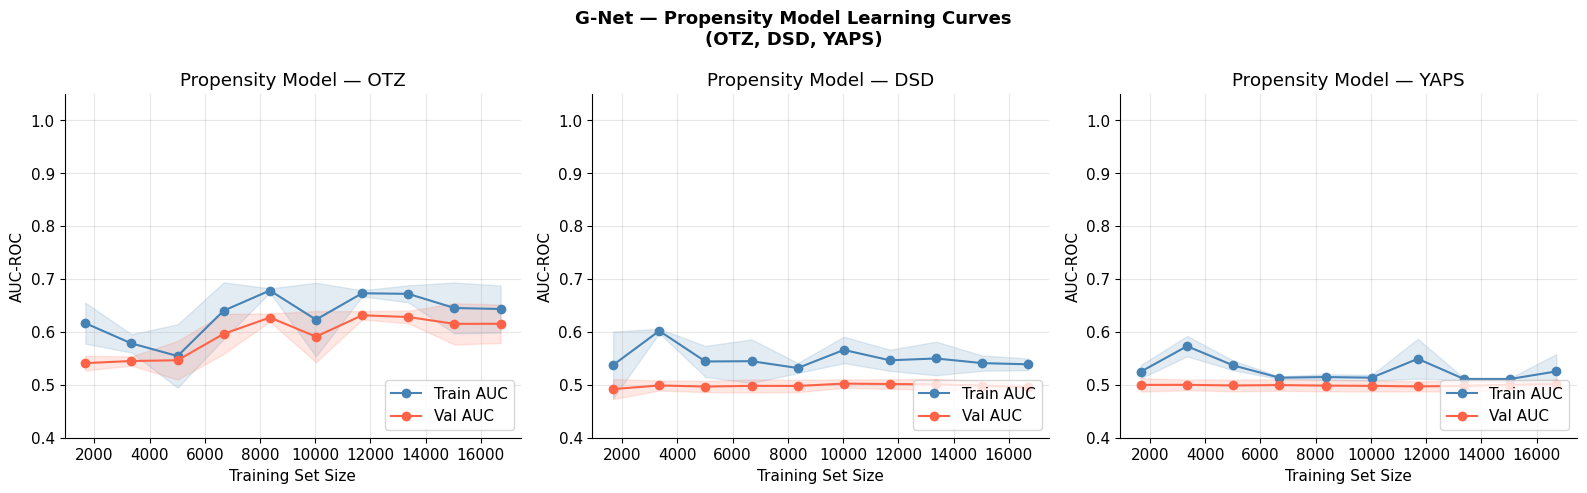

In [5]:
# ============================================================
# TRAINING CURVES — Propensity Models Learning Curves
# ============================================================
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

TREAT_LABELS = {
    'enrolled_in_OTZ':  'OTZ',
    'enrolled_in_DSD':  'DSD',
    'has_YAPS_support': 'YAPS'
}
TREATMENTS = ['enrolled_in_OTZ', 'enrolled_in_DSD', 'has_YAPS_support']

BASE_COVS = [
    'age','sex','years_on_ART','baseline_CD4','BMI','distance_to_clinic_km',
    'stigma_score','social_support_score','PHQ9_score','alcohol_AUDITC_score',
    'caregiver_support','food_insecurity','treatment_interruption'
]
base_idx = [FEATURE_COLS.index(c) for c in BASE_COVS if c in FEATURE_COLS]

# ── Use a SEPARATE scaler — never touch the main scaler ────
prop_scaler  = StandardScaler()                            # ← NEW variable name
X_base_scaled = prop_scaler.fit_transform(X[:, base_idx]) # ← 13 cols only
# ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, t in enumerate(TREATMENTS):
    label  = TREAT_LABELS[t]
    t_idx  = FEATURE_COLS.index(t)
    A_full = X[:, t_idx].astype(int)

    prop_lc = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1
    )

    train_sizes, train_scores, val_scores = learning_curve(
        prop_lc,
        X_base_scaled,   # ← uses prop_scaler, NOT main scaler
        A_full,
        cv=5,
        scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    vl_mean = val_scores.mean(axis=1)
    vl_std  = val_scores.std(axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train AUC')
    ax.plot(train_sizes, vl_mean, 'o-', color='tomato',    label='Val AUC')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std,
                    alpha=0.15, color='tomato')
    ax.set_title(f'Propensity Model — {label}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('AUC-ROC')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.4, 1.05)

plt.suptitle('G-Net — Propensity Model Learning Curves\n(OTZ, DSD, YAPS)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gnet_propensity_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
#  G-Net Step 1: Propensity Models
# These model P(A=1 | L) — the probability of receiving each intervention
# given baseline covariates. Used to characterise selection bias.

BASE_COVS = [
    'age','sex','years_on_ART','baseline_CD4','BMI','distance_to_clinic_km',
    'stigma_score','social_support_score','PHQ9_score','alcohol_AUDITC_score',
    'caregiver_support','food_insecurity','treatment_interruption'
]

base_idx   = [FEATURE_COLS.index(c) for c in BASE_COVS if c in FEATURE_COLS]
X_base_tr  = X_train_s[:, base_idx]
X_base_te  = X_test_s[:,  base_idx]

prop_models   = {}
prop_auc      = {}
TREAT_LABELS  = {'enrolled_in_OTZ':'OTZ','enrolled_in_DSD':'DSD','has_YAPS_support':'YAPS'}

for t in TREATMENTS:
    t_idx   = FEATURE_COLS.index(t)
    A_train = X_train[:, t_idx].astype(int)
    A_test  = X_test[:,  t_idx].astype(int)

    m = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1
    )
    m.fit(X_base_tr, A_train)
    auc = roc_auc_score(A_test, m.predict_proba(X_base_te)[:, 1])
    prop_models[t] = m
    prop_auc[t]    = auc
    print(f"  Propensity [{TREAT_LABELS[t]}]  AUC = {auc:.4f}")

print("\nPropensity models fitted.")


  Propensity [OTZ]  AUC = 0.6226
  Propensity [DSD]  AUC = 0.5128
  Propensity [YAPS]  AUC = 0.4914

Propensity models fitted.


In [7]:
# ── G-Net Step 2: Outcome Model ──────────────────────────────────────────
# Predicts P(Y=1 | A, L) — suppression probability given all features

gnet_outcome = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
gnet_outcome.fit(X_train_s, y_train)

gnet_probs  = gnet_outcome.predict_proba(X_test_s)[:, 1]
gnet_preds  = (gnet_probs >= 0.5).astype(int)
gnet_auc    = roc_auc_score(y_test, gnet_probs)

print(f"G-Net Outcome Model — ROC-AUC: {gnet_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gnet_preds, target_names=['Not Suppressed','Suppressed']))


G-Net Outcome Model — ROC-AUC: 0.9659

Classification Report:
                precision    recall  f1-score   support

Not Suppressed       0.91      0.92      0.92      2342
    Suppressed       0.90      0.89      0.89      1836

      accuracy                           0.91      4178
     macro avg       0.91      0.91      0.91      4178
  weighted avg       0.91      0.91      0.91      4178



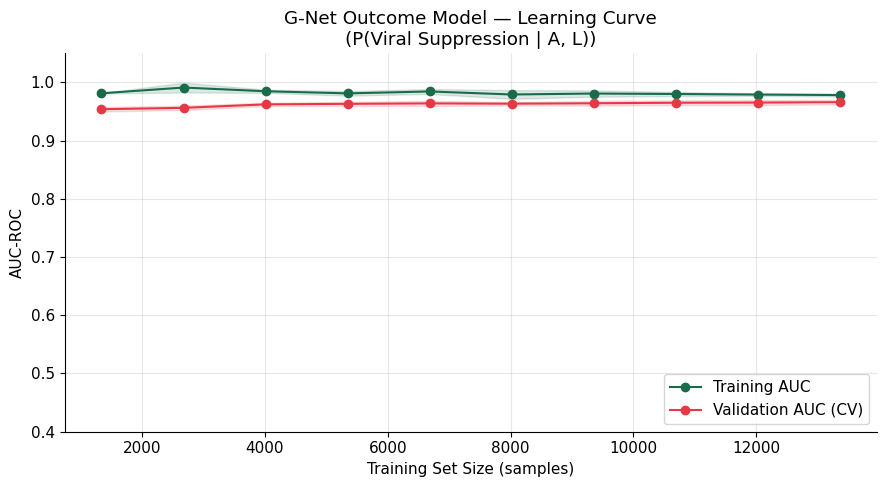

Final Training AUC:   0.978 ± 0.002
Final Validation AUC: 0.966  ± 0.004


In [8]:
# ============================================================
# TRAINING CURVES — G-Net Outcome Model Learning Curve
# ============================================================
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

train_sizes, train_scores, val_scores = learning_curve(
    MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ),
    X_train_s, y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
vl_mean = val_scores.mean(axis=1)
vl_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='#1a6b4a', label='Training AUC')
ax.plot(train_sizes, vl_mean, 'o-', color='#e63946', label='Validation AUC (CV)')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='#1a6b4a')
ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std,
                alpha=0.15, color='#e63946')
ax.set_xlabel('Training Set Size (samples)')
ax.set_ylabel('AUC-ROC')
ax.set_title('G-Net Outcome Model — Learning Curve\n(P(Viral Suppression | A, L))')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig('gnet_outcome_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Training AUC:   {tr_mean[-1]:.3f} ± {tr_std[-1]:.3f}")
print(f"Final Validation AUC: {vl_mean[-1]:.3f}  ± {vl_std[-1]:.3f}")

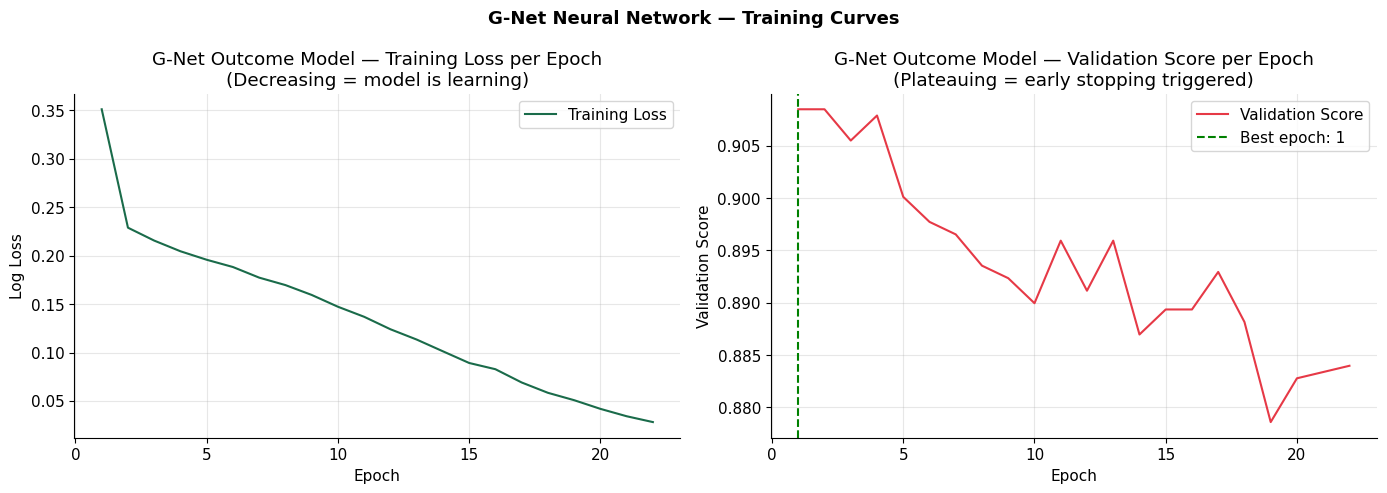

Total epochs trained : 22
Best validation epoch: 1
Final training loss  : 0.0282


In [9]:
# ============================================================
# TRAINING CURVES — MLP Loss per Epoch (Train vs Validation)
# This is the neural network equivalent of the loss curve
# ============================================================
import matplotlib.pyplot as plt

# The outcome model already has loss history from early_stopping=True
train_loss_curve = gnet_outcome.loss_curve_
val_loss_curve   = gnet_outcome.validation_scores_   # validation score per epoch

epochs = range(1, len(train_loss_curve) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs, train_loss_curve, color='#1a6b4a', label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('G-Net Outcome Model — Training Loss per Epoch\n(Decreasing = model is learning)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation score curve
val_epochs = range(1, len(val_loss_curve) + 1)
axes[1].plot(val_epochs, val_loss_curve, color='#e63946', label='Validation Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Score')
axes[1].set_title('G-Net Outcome Model — Validation Score per Epoch\n(Plateauing = early stopping triggered)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Mark where early stopping occurred
best_epoch = int(np.argmax(val_loss_curve)) + 1
axes[1].axvline(x=best_epoch, color='green', linestyle='--',
                label=f'Best epoch: {best_epoch}')
axes[1].legend()

plt.suptitle('G-Net Neural Network — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gnet_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total epochs trained : {len(train_loss_curve)}")
print(f"Best validation epoch: {best_epoch}")
print(f"Final training loss  : {train_loss_curve[-1]:.4f}")


In [10]:
# ── G-Net Step 3: G-Computation Counterfactuals ─────────────────────────
# For each treatment: set A=1 for ALL patients, then A=0 for ALL patients
# ATE = E[Y(1)] - E[Y(0)]

gnet_ate     = {}
gnet_cate_df = pd.DataFrame({'y_true': y_test})

for t in TREATMENTS:
    label  = TREAT_LABELS[t]
    t_idx  = FEATURE_COLS.index(t)

    # Counterfactual: everyone treated
    X_cf1      = X_test_df.copy()
    X_cf1[t]   = 1
    X_cf1_s    = scaler.transform(X_cf1.values)   # ← FIXED: use .values (all 60 features)
    p1         = gnet_outcome.predict_proba(X_cf1_s)[:, 1]

    # Counterfactual: no one treated
    X_cf0      = X_test_df.copy()
    X_cf0[t]   = 0
    X_cf0_s    = scaler.transform(X_cf0.values)   # ← FIXED: use .values (all 60 features)
    p0         = gnet_outcome.predict_proba(X_cf0_s)[:, 1]

    ate  = p1.mean() - p0.mean()
    cate = p1 - p0

    gnet_ate[label]               = {'E_Y1': p1.mean(), 'E_Y0': p0.mean(), 'ATE': ate}
    gnet_cate_df[f'CATE_{label}'] = cate

    print(f"  [{label}]  E[Y|A=1]={p1.mean():.4f}  E[Y|A=0]={p0.mean():.4f}  ATE={ate:+.4f}")

print("\nG-computation complete.")

  [OTZ]  E[Y|A=1]=0.4621  E[Y|A=0]=0.4219  ATE=+0.0402
  [DSD]  E[Y|A=1]=0.4522  E[Y|A=0]=0.4175  ATE=+0.0347
  [YAPS]  E[Y|A=1]=0.4355  E[Y|A=0]=0.4331  ATE=+0.0024

G-computation complete.


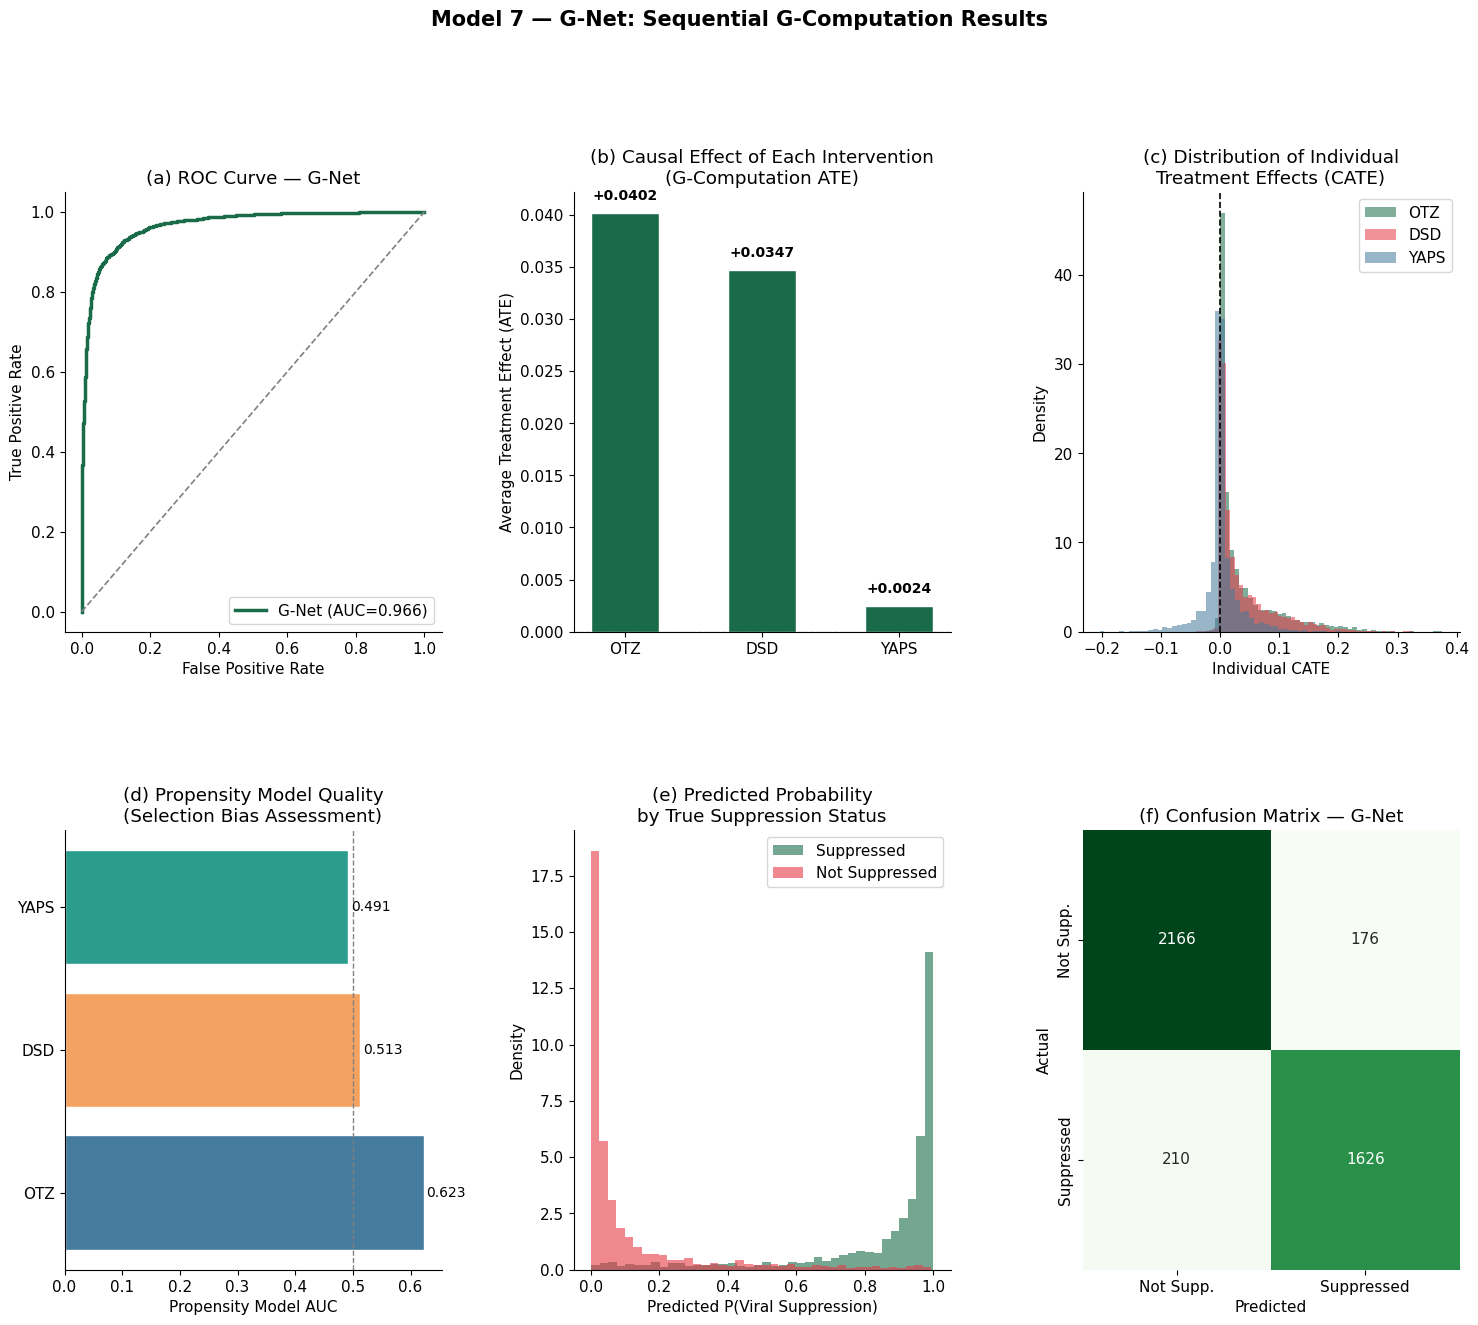


G-Net Summary: AUC=0.9659 | Best ATE: OTZ=+0.0402


In [11]:
# ── G-Net Visualisation ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) ROC Curve ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, gnet_probs)
ax1.plot(fpr, tpr, color=PALETTE[0], lw=2.5, label=f"G-Net (AUC={gnet_auc:.3f})")
ax1.plot([0,1],[0,1],'--', color='grey', lw=1.2)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("(a) ROC Curve — G-Net"); ax1.legend()

# ── (b) ATE bar chart ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
labels = list(gnet_ate.keys())
ates   = [gnet_ate[l]['ATE'] for l in labels]
colors = [PALETTE[0] if a > 0 else PALETTE[1] for a in ates]
bars   = ax2.bar(labels, ates, color=colors, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_ylabel("Average Treatment Effect (ATE)")
ax2.set_title("(b) Causal Effect of Each Intervention\n(G-Computation ATE)")
for bar, ate in zip(bars, ates):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f"{ate:+.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── (c) CATE distributions ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for i, t in enumerate(['OTZ','DSD','YAPS']):
    ax3.hist(gnet_cate_df[f'CATE_{t}'], bins=50, alpha=0.55,
             color=PALETTE[i], label=t, density=True)
ax3.axvline(0, color='black', lw=1.2, ls='--')
ax3.set_xlabel("Individual CATE"); ax3.set_ylabel("Density")
ax3.set_title("(c) Distribution of Individual\nTreatment Effects (CATE)")
ax3.legend()

# ── (d) Propensity AUC bar ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
p_labels = [TREAT_LABELS[t] for t in TREATMENTS]
p_aucs   = [prop_auc[t] for t in TREATMENTS]
ax4.barh(p_labels, p_aucs, color=PALETTE[2:5], edgecolor='white')
ax4.axvline(0.5, color='grey', ls='--', lw=1)
ax4.set_xlabel("Propensity Model AUC")
ax4.set_title("(d) Propensity Model Quality\n(Selection Bias Assessment)")
for i, (v, l) in enumerate(zip(p_aucs, p_labels)):
    ax4.text(v+0.005, i, f"{v:.3f}", va='center', fontsize=10)

# ── (e) Predicted probability by suppression status ──────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for sup, col, lbl in zip([1,0], [PALETTE[0], PALETTE[1]],
                          ['Suppressed','Not Suppressed']):
    ax5.hist(gnet_probs[y_test==sup], bins=40, alpha=0.6,
             color=col, label=lbl, density=True)
ax5.set_xlabel("Predicted P(Viral Suppression)")
ax5.set_ylabel("Density")
ax5.set_title("(e) Predicted Probability\nby True Suppression Status")
ax5.legend()

# ── (f) Confusion matrix ──────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
cm  = confusion_matrix(y_test, gnet_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Supp.','Suppressed'],
            yticklabels=['Not Supp.','Suppressed'], ax=ax6, cbar=False)
ax6.set_xlabel("Predicted"); ax6.set_ylabel("Actual")
ax6.set_title("(f) Confusion Matrix — G-Net")

fig.suptitle("Model 7 — G-Net: Sequential G-Computation Results",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f"\nG-Net Summary: AUC={gnet_auc:.4f} | Best ATE: OTZ={gnet_ate['OTZ']['ATE']:+.4f}")


In [12]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

# Accuracy metrics
accuracy          = accuracy_score(y_test, gnet_preds)
balanced_accuracy = balanced_accuracy_score(y_test, gnet_preds)
auc               = roc_auc_score(y_test, gnet_probs)

print("=" * 40)
print("       G-Net Model Accuracy Summary")
print("=" * 40)
print(f"  Accuracy          : {accuracy*100:.2f}%")
print(f"  Balanced Accuracy : {balanced_accuracy*100:.2f}%")
print(f"  ROC-AUC           : {auc:.4f}")
print("=" * 40)

       G-Net Model Accuracy Summary
  Accuracy          : 90.76%
  Balanced Accuracy : 90.52%
  ROC-AUC           : 0.9659


In [14]:
import joblib

bundle = {
    "outcome_model": gnet_outcome,
    "prop_models": prop_models,
    "scaler": scaler,
    "feature_cols": FEATURE_COLS,
    "treatments": TREATMENTS,
    "treat_labels": TREAT_LABELS,
    "gnet_ate": gnet_ate
}

joblib.dump(bundle, "gnet_bundle.joblib")

print("✅ Model saved successfully!")

✅ Model saved successfully!
